# Prediksi Indeks Kualitas Air (IKA) Kabupaten/Kota di Indonesia

**Dataset:** `Indeks_Kualitas_Air__IKA__Tahun_2022_-_2025.csv` — nilai IKA per kabupaten/kota dan per provinsi, tahun 2022–2025.

**Tujuan:** memprediksi **IKA tahun 2025** suatu kabupaten/kota berdasarkan IKA tahun 2022–2024 dan provinsinya (*forecasting* satu tahun ke depan).

**Jenis masalah:** regresi (target berupa angka kontinu, skala 0–100; semakin tinggi semakin baik).

**Alur notebook:** import library → load data → pahami & bersihkan data → EDA → rekayasa fitur → split data → preprocessing → bandingkan model → evaluasi → interpretasi → simpan & pakai model.

> **Catatan perbaikan:** versi notebook sebelumnya dibuat untuk dataset lain (sampel dengan kolom pH, BOD, COD, `Kualitas_Air`, dst.), sehingga tidak bisa dijalankan pada file CSV ini. Notebook ini ditulis ulang agar sesuai dengan struktur data IKA yang sebenarnya, dan path file yang tadinya terkunci ke folder komputer tertentu diganti menjadi path relatif.

## 1. Import Library & Pengaturan

Bagian ini memuat semua library yang dibutuhkan di satu tempat supaya mudah dilacak:
- `pandas` / `numpy` untuk mengolah data,
- `matplotlib` / `seaborn` untuk visualisasi,
- `scikit-learn` untuk preprocessing, model, validasi silang, dan metrik,
- `joblib` untuk menyimpan model.

Ada tiga pengaturan penting: `DATA_PATH` (lokasi CSV), `OUTPUT_DIR` (folder hasil) dan `RANDOM_STATE` (angka acak tetap agar hasil bisa direproduksi). **Path sekarang relatif**, jadi cukup letakkan file CSV di folder yang sama dengan notebook (di Google Colab, unggah file CSV lalu jalankan). Ubah `DATA_PATH` jika lokasi file Anda berbeda.

In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

DATA_PATH = "Indeks_Kualitas_Air__IKA__Tahun_2022_-_2025.csv"
OUTPUT_DIR = "hasil_model"
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Data

Membaca file CSV ke dalam DataFrame `df`. Pengecekan `os.path.exists` ditambahkan agar jika file tidak ditemukan, pesan errornya jelas (bukan error panjang dari pandas). Kita juga mencetak ukuran data dan beberapa baris pertama untuk memastikan data terbaca dengan benar.

In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"File '{DATA_PATH}' tidak ditemukan. Letakkan CSV di folder yang sama dengan notebook "
        "atau ubah nilai DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print("Ukuran data (baris, kolom):", df.shape)
df.head()

Ukuran data (baris, kolom): (552, 8)


,kedalaman,kode_referensi,kabkota,provinsi,ika_2022,ika_2023,ika_2024,ika_2025
0,KABKOTA,5104,Kabupaten Gianyar,Bali,65.06,74.38,73.44,73.41
1,KABKOTA,5107,Kabupaten Karangasem,Bali,79.86,80.22,82.58,75.48
2,KABKOTA,5108,Kabupaten Buleleng,Bali,70.53,73.65,75.02,82.76
3,KABKOTA,5101,Kabupaten Jembrana,Bali,73.36,77.45,76.15,80.30
4,KABKOTA,5171,Kota Denpasar,Bali,61.74,65.50,66.58,72.41


## 3. Memahami Struktur Data

Kolom pada dataset:

| Kolom | Arti |
|---|---|
| `kedalaman` | Tingkat wilayah: `KABKOTA` (kabupaten/kota) atau `PROV` (rekap provinsi) |
| `kode_referensi` | Kode wilayah (BPS/Kemendagri) |
| `kabkota` | Nama kabupaten/kota (untuk baris provinsi berisi nama provinsi) |
| `provinsi` | Nama provinsi |
| `ika_2022` … `ika_2025` | Indeks Kualitas Air per tahun (0–100) |

Dua hal perlu diperhatikan, dan keduanya dicek pada sel di bawah:
1. **Data campuran dua level.** Baris `PROV` adalah agregat dari kabupaten/kota. Jika ikut dimasukkan ke pelatihan, data akan tercampur antara level yang berbeda (dan provinsi dihitung ganda).
2. **Ada nilai kosong (missing value)** di semua kolom IKA, terutama `ika_2022`. Ini harus ditangani, bukan diabaikan.

In [3]:
print("Jumlah baris per level wilayah:")
print(df["kedalaman"].value_counts())
print()
print("Missing value per kolom:")
print(df.isna().sum())
print()
df.describe().T

Jumlah baris per level wilayah:
kedalaman
KABKOTA    514
PROV        38
Name: count, dtype: int64

Missing value per kolom:
kedalaman           0
kode_referensi      0
kabkota             0
provinsi            0
ika_2022          107
ika_2023           26
ika_2024           11
ika_2025           54
dtype: int64



,count,mean,std,min,25%,50%,75%,max
kode_referensi,552.0,4271.429348,2844.835559,11.00,1602.75,3511.50,7106.2500,9708.00
ika_2022,445.0,71.692921,6.362896,46.94,68.35,72.55,75.9900,86.86
ika_2023,526.0,72.560913,6.718807,44.08,69.84,73.30,76.4675,92.02
ika_2024,541.0,72.210499,6.580359,43.24,68.99,72.91,75.8900,89.22
ika_2025,498.0,72.181546,6.337205,51.54,68.23,72.60,76.5950,87.70


## 4. Pembersihan Data

Langkah yang dilakukan:
1. Memisahkan baris **provinsi** (`df_prov`) dari baris **kabupaten/kota** (`df_kab`). Data provinsi disimpan untuk keperluan visualisasi, sedangkan pemodelan hanya memakai kabupaten/kota.
2. Membuang baris kabupaten/kota yang **`ika_2025`-nya kosong**. Karena `ika_2025` adalah target, baris tanpa target tidak bisa dipakai untuk belajar maupun menguji. Nilai target *tidak boleh* diisi/ditebak.
3. Nilai kosong pada fitur (`ika_2022`–`ika_2024`) **dibiarkan dulu** dan diisi nanti di dalam pipeline (bagian 8), agar imputasi hanya belajar dari data latih.

In [4]:
df_prov = df[df["kedalaman"] == "PROV"].copy()
df_kab = df[df["kedalaman"] == "KABKOTA"].copy()

sebelum = len(df_kab)
df_kab = df_kab.dropna(subset=["ika_2025"]).reset_index(drop=True)

print(f"Kab/kota awal            : {sebelum}")
print(f"Dibuang (target kosong)  : {sebelum - len(df_kab)}")
print(f"Kab/kota dipakai         : {len(df_kab)}")
print(f"Baris tanpa satupun IKA 2022-2024: {df_kab[['ika_2022','ika_2023','ika_2024']].isna().all(axis=1).sum()}")

Kab/kota awal            : 514
Dibuang (target kosong)  : 54
Kab/kota dipakai         : 460
Baris tanpa satupun IKA 2022-2024: 0


## 5. Eksplorasi Data (EDA)

EDA membantu memahami pola sebelum memodelkan. Ada empat visualisasi:
1. **Distribusi IKA per tahun** — apakah sebarannya mirip antar tahun dan adakah nilai ekstrem.
2. **Rata-rata IKA per tahun** — apakah ada tren naik/turun secara umum.
3. **Korelasi antar tahun** — seberapa kuat IKA tahun lalu menjelaskan tahun berikutnya. Korelasi tinggi menandakan tahun-tahun sebelumnya adalah prediktor yang berguna.
4. **IKA 2025 per provinsi** — provinsi mana yang paling baik dan paling rendah.

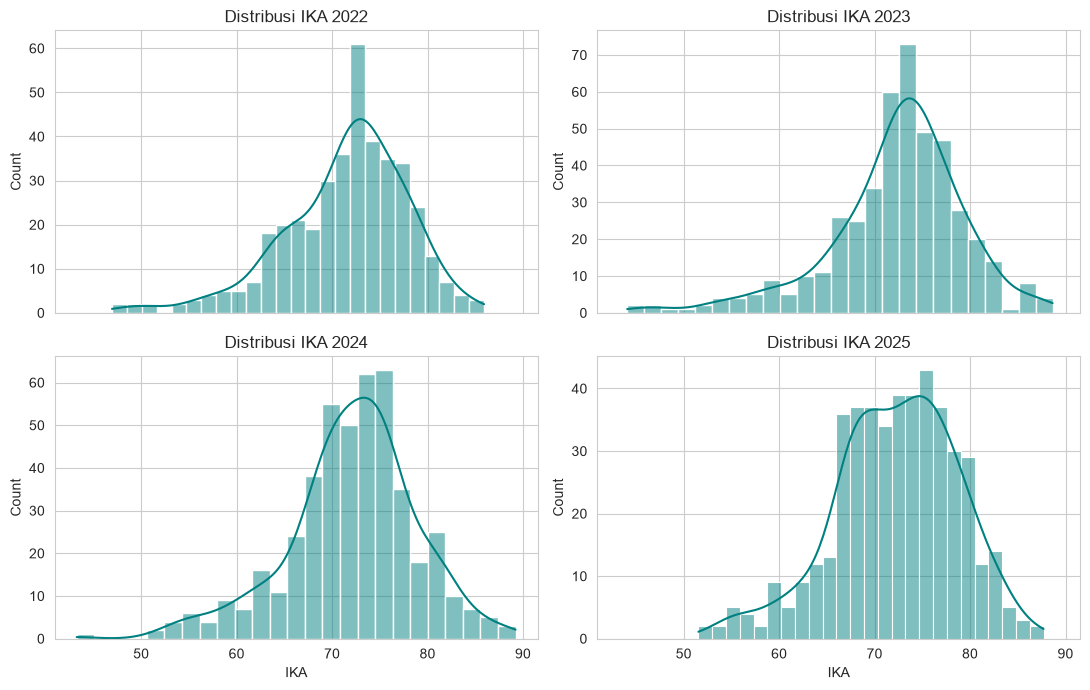

In [5]:
kolom_ika = ["ika_2022", "ika_2023", "ika_2024", "ika_2025"]

# 1) Distribusi per tahun
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, kolom in zip(axes.ravel(), kolom_ika):
    sns.histplot(df_kab[kolom].dropna(), bins=25, kde=True, color="teal", ax=ax)
    ax.set_title(f"Distribusi {kolom.upper().replace('_', ' ')}")
    ax.set_xlabel("IKA")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribusi_ika.png"), dpi=150)
plt.show()

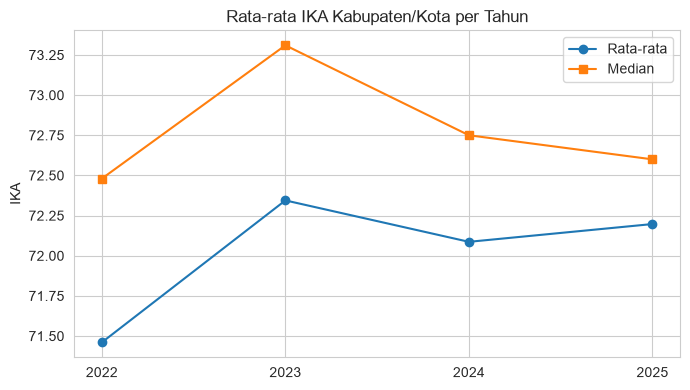

ika_2022    71.46
ika_2023    72.34
ika_2024    72.09
ika_2025    72.20
dtype: float64


In [6]:
# 2) Rata-rata & median per tahun
rata = df_kab[kolom_ika].mean()
median = df_kab[kolom_ika].median()
tahun = [c.split("_")[1] for c in kolom_ika]

plt.figure(figsize=(7, 4))
plt.plot(tahun, rata.values, marker="o", label="Rata-rata")
plt.plot(tahun, median.values, marker="s", label="Median")
plt.title("Rata-rata IKA Kabupaten/Kota per Tahun")
plt.ylabel("IKA")
plt.legend()
plt.tight_layout()
plt.show()
print(rata.round(2))

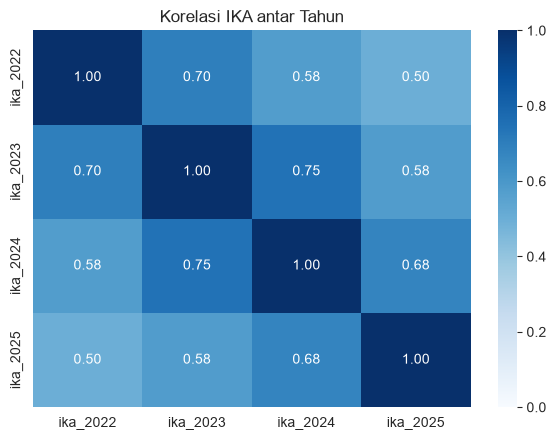

In [7]:
# 3) Korelasi antar tahun
plt.figure(figsize=(6, 4.5))
sns.heatmap(df_kab[kolom_ika].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Korelasi IKA antar Tahun")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "korelasi_ika.png"), dpi=150)
plt.show()

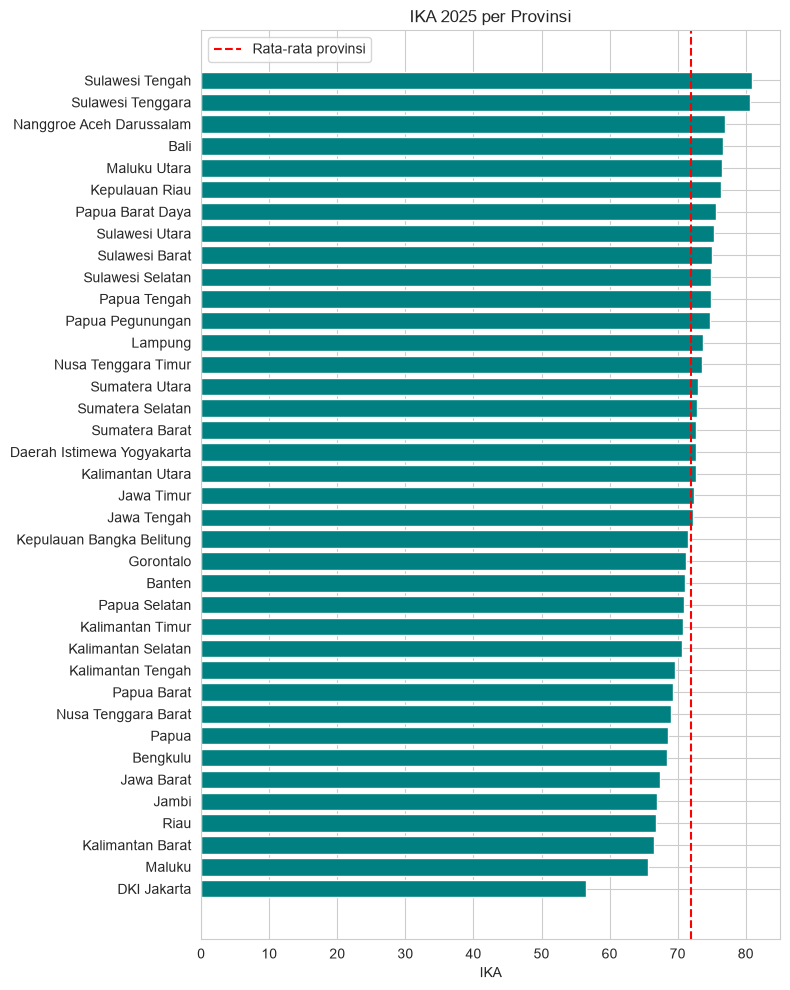

In [8]:
# 4) IKA 2025 per provinsi (dari baris level PROV)
prov_2025 = df_prov.dropna(subset=["ika_2025"]).sort_values("ika_2025")

plt.figure(figsize=(8, 10))
plt.barh(prov_2025["provinsi"], prov_2025["ika_2025"], color="teal")
plt.axvline(prov_2025["ika_2025"].mean(), color="red", linestyle="--", label="Rata-rata provinsi")
plt.title("IKA 2025 per Provinsi")
plt.xlabel("IKA")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Rekayasa Fitur (Feature Engineering)

Fitur yang dipakai:
- **`ika_2022`, `ika_2023`, `ika_2024`** — riwayat IKA masing-masing kabupaten/kota.
- **`rata_riwayat`** — rata-rata IKA yang tersedia (nilai kosong otomatis diabaikan). Berguna untuk meredam fluktuasi satu tahun dan sebagai cadangan bila salah satu tahun kosong.
- **`tren`** — selisih `ika_2024 − ika_2023`, menggambarkan arah perubahan terbaru.
- **`provinsi`** — fitur kategori; kabupaten/kota dalam satu provinsi cenderung memiliki kondisi lingkungan serupa.

Yang **sengaja tidak dipakai**: `kode_referensi` dan `kabkota` (hanya pengenal unik, tidak informatif dan mendorong *overfitting*), serta `kedalaman` (sudah konstan setelah pemisahan). Fungsi `buat_fitur` dibuat terpisah agar **perhitungan yang sama** bisa dipakai lagi saat memprediksi data baru (bagian 13).

In [10]:
riwayat = ["ika_2022", "ika_2023", "ika_2024"]
fitur_numerik = riwayat + ["rata_riwayat", "tren"]
fitur_kategori = ["provinsi"]


def buat_fitur(data: pd.DataFrame) -> pd.DataFrame:
    """Menambahkan fitur turunan (rata-rata riwayat & tren) ke DataFrame."""
    data = data.copy()
    data["rata_riwayat"] = data[riwayat].mean(axis=1)   # NaN diabaikan otomatis
    data["tren"] = data["ika_2024"] - data["ika_2023"]  # NaN jika salah satu kosong
    return data[fitur_numerik + fitur_kategori]


X = buat_fitur(df_kab)
y = df_kab["ika_2025"]
X.head()

,ika_2022,ika_2023,ika_2024,rata_riwayat,tren,provinsi
0,65.06,74.38,73.44,70.960000,-0.94,Bali
1,79.86,80.22,82.58,80.886667,2.36,Bali
2,70.53,73.65,75.02,73.066667,1.37,Bali
3,73.36,77.45,76.15,75.653333,-1.30,Bali
4,61.74,65.50,66.58,64.606667,1.08,Bali


## 7. Split Data (80% latih, 20% uji)

Data dibagi menjadi **data latih** (untuk belajar dan memilih model) dan **data uji** (disimpan sampai akhir untuk menilai performa secara jujur pada data yang belum pernah dilihat model). `random_state` dikunci agar pembagian selalu sama. Stratifikasi tidak dipakai karena targetnya kontinu.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Data latih: {X_train.shape[0]} | Data uji: {X_test.shape[0]}")

Data latih: 368 | Data uji: 92


## 8. Preprocessing

Pipeline preprocessing memastikan semua transformasi hanya *belajar* dari data latih (mencegah kebocoran informasi dari data uji):
- **Numerik:** nilai kosong diisi **median**; `add_indicator=True` menambah kolom penanda "nilai ini tadinya kosong" (kekosongan data bisa jadi informasi); lalu **standarisasi** (rata-rata 0, simpangan baku 1) supaya skala fitur seragam — penting untuk model linear.
- **Kategori (`provinsi`):** nilai kosong diisi modus, lalu **One-Hot Encoding**. `handle_unknown="ignore"` membuat model tidak error bila ada provinsi yang tidak ada di data latih.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]), fitur_numerik),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), fitur_kategori),
    ]
)

## 9. Baseline & Perbandingan Model (Cross Validation 5-fold)

**Baseline** adalah patokan paling sederhana: *"IKA tahun depan sama dengan IKA tahun lalu"* (`ika_2024`; jika kosong dipakai rata-rata riwayat, dan jika masih kosong dipakai rata-rata data latih). Model machine learning hanya bermanfaat jika **mengalahkan baseline ini**.

Tiga kandidat model dibandingkan dengan **validasi silang 5-fold** pada data latih, menggunakan **MAE** (rata-rata selisih absolut, dalam satuan poin IKA; makin kecil makin baik):
- **Ridge Regression** — model linear dengan regularisasi, sederhana dan stabil untuk data kecil.
- **Random Forest** — kumpulan pohon keputusan, menangkap pola non-linear.
- **Gradient Boosting** — pohon yang dibangun bertahap untuk memperbaiki kesalahan sebelumnya.

Model dengan MAE validasi silang terkecil dipilih otomatis. Data uji **belum disentuh** di tahap ini.

In [13]:
def baseline_naif(data: pd.DataFrame, rata_latih: float) -> pd.Series:
    """IKA tahun depan = IKA tahun terakhir (cadangan: rata-rata riwayat, lalu rata-rata latih)."""
    return data["ika_2024"].fillna(data["rata_riwayat"]).fillna(rata_latih)


kandidat = {
    "Ridge Regression": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150, max_depth=2, learning_rate=0.05, random_state=RANDOM_STATE
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline pada data latih (sebagai pembanding CV)
mae_baseline_latih = mean_absolute_error(y_train, baseline_naif(X_train, y_train.mean()))
print(f"{'Baseline (IKA 2024)':22s}: MAE = {mae_baseline_latih:.4f}")

hasil_cv = {}
for nama, model in kandidat.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    skor = -cross_val_score(pipe, X_train, y_train, cv=cv,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
    hasil_cv[nama] = skor.mean()
    print(f"{nama:22s}: MAE = {skor.mean():.4f} (+/- {skor.std():.4f})")

model_terbaik_nama = min(hasil_cv, key=hasil_cv.get)
print(f"\nModel terbaik (MAE CV terkecil): {model_terbaik_nama}")

Baseline (IKA 2024)   : MAE = 3.8305
Ridge Regression      : MAE = 3.5463 (+/- 0.3051)
Random Forest         : MAE = 3.7747 (+/- 0.2568)
Gradient Boosting     : MAE = 3.6832 (+/- 0.3217)

Model terbaik (MAE CV terkecil): Ridge Regression


## 10. Latih Model Terbaik & Evaluasi pada Data Uji

Model terbaik dilatih ulang pada **seluruh data latih**, lalu diuji **sekali** pada data uji. Metrik yang dilaporkan:
- **MAE** — rata-rata kesalahan dalam poin IKA (mudah diinterpretasi).
- **RMSE** — seperti MAE tetapi lebih menghukum kesalahan besar.
- **R²** — proporsi variasi target yang dijelaskan model (1 = sempurna, 0 = sama buruknya dengan menebak rata-rata).

Hasil dibandingkan langsung dengan baseline pada data uji yang sama. Grafik *aktual vs prediksi* menunjukkan seberapa dekat titik-titik ke garis diagonal (prediksi sempurna).

In [ ]:
model_final = Pipeline([
    ("prep", preprocessor),
    ("model", kandidat[model_terbaik_nama]),
])
model_final.fit(X_train, y_train)

y_pred = model_final.predict(X_test)
y_base = baseline_naif(X_test, y_train.mean())


def ringkas(y_true, y_hat):
    return {
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R2": r2_score(y_true, y_hat),
    }


tabel_hasil = pd.DataFrame({
    "Baseline (IKA 2024)": ringkas(y_test, y_base),
    model_terbaik_nama: ringkas(y_test, y_pred),
}).T.round(4)
tabel_hasil

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor="white")
batas = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(batas, batas, "r--", label="Prediksi sempurna")
plt.xlabel("IKA 2025 aktual")
plt.ylabel("IKA 2025 prediksi")
plt.title(f"Aktual vs Prediksi - {model_terbaik_nama}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "aktual_vs_prediksi.png"), dpi=150)
plt.show()

## 11. Analisis dengan Kategori IKA

Nilai IKA sering dibaca dalam kategori. Di sini prediksi angka diubah menjadi kategori memakai ambang yang umum dipakai pada Indeks Kualitas Lingkungan Hidup (KLHK): **Sangat Baik** (≥ 90), **Baik** (70 – <90), **Sedang** (50 – <70), **Kurang** (25 – <50), **Sangat Kurang** (< 25). *(Ambang ini dipakai sebagai asumsi; sesuaikan bila Anda memakai acuan lain.)*

*Confusion matrix* menunjukkan berapa kabupaten/kota yang kategori aktualnya (baris) diprediksi masuk ke kategori tertentu (kolom). Angka di diagonal = prediksi kategori tepat. Kesalahan biasanya terjadi di sekitar batas kategori (mis. IKA 69,8 vs 70,1).

In [ ]:
def ke_kategori(nilai):
    return pd.cut(
        nilai, bins=[-np.inf, 25, 50, 70, 90, np.inf], right=False,
        labels=["Sangat Kurang", "Kurang", "Sedang", "Baik", "Sangat Baik"],
    )


kat_aktual = ke_kategori(y_test)
kat_prediksi = ke_kategori(pd.Series(y_pred, index=y_test.index))

urutan = [k for k in ["Sangat Kurang", "Kurang", "Sedang", "Baik", "Sangat Baik"]
          if k in set(kat_aktual.astype(str)) | set(kat_prediksi.astype(str))]

cm = confusion_matrix(kat_aktual.astype(str), kat_prediksi.astype(str), labels=urutan)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=urutan, yticklabels=urutan)
plt.xlabel("Kategori prediksi")
plt.ylabel("Kategori aktual")
plt.title("Confusion Matrix Kategori IKA 2025")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_kategori.png"), dpi=150)
plt.show()

akurasi_kategori = (kat_aktual.astype(str).values == kat_prediksi.astype(str).values).mean()
print(f"Akurasi kategori: {akurasi_kategori:.2%}")

## 12. Faktor yang Paling Berpengaruh

Bagian ini menunjukkan fitur mana yang paling menentukan prediksi:
- Untuk model berbasis pohon (Random Forest / Gradient Boosting) dipakai `feature_importances_`.
- Untuk model linear (Ridge) dipakai **koefisien** yang diurutkan berdasarkan nilai mutlaknya; karena fitur sudah distandarisasi, besar koefisien bisa dibandingkan antar fitur. Koefisien positif berarti nilai fitur yang lebih tinggi menaikkan prediksi IKA 2025.

Nama fitur hasil One-Hot (mis. `provinsi_Jawa Barat`) ikut ditampilkan sehingga terlihat apakah provinsi tertentu punya efek khusus.

In [ ]:
estimator = model_final.named_steps["model"]
nama_fitur = [n.split("__", 1)[1] for n in model_final.named_steps["prep"].get_feature_names_out()]

if hasattr(estimator, "feature_importances_"):
    nilai = pd.Series(estimator.feature_importances_, index=nama_fitur)
    judul = "Feature Importance (15 teratas)"
else:
    nilai = pd.Series(estimator.coef_, index=nama_fitur)
    judul = "Koefisien Model (15 terbesar berdasarkan nilai mutlak)"

top = nilai.reindex(nilai.abs().sort_values(ascending=False).head(15).index).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values, color=np.where(top.values >= 0, "teal", "indianred"))
plt.title(judul)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pengaruh_fitur.png"), dpi=150)
plt.show()

print(nilai.reindex(nilai.abs().sort_values(ascending=False).head(10).index).round(4))

## 13. Simpan Model

Seluruh pipeline (preprocessing + model) disimpan dalam satu file `.joblib`. Dengan begitu, saat model dipakai kembali, langkah pengisian nilai kosong, standarisasi, dan One-Hot Encoding otomatis ikut berjalan tanpa perlu diulang manual.

In [ ]:
path_model = os.path.join(OUTPUT_DIR, "model_ika.joblib")
joblib.dump(model_final, path_model)
print(f"Model disimpan di: {path_model}")

## 14. Prediksi Data Baru

Fungsi `prediksi_ika_2025` menerima riwayat IKA satu kabupaten/kota beserta provinsinya, lalu mengembalikan prediksi IKA 2025 dan kategorinya. Nilai riwayat yang tidak diketahui boleh diisi `None` — model sudah dilatih untuk menangani nilai kosong. Fitur turunan (`rata_riwayat`, `tren`) dihitung otomatis lewat `buat_fitur` yang sama seperti saat pelatihan. Nama provinsi harus sesuai penulisan di dataset (mis. `Jawa Barat`, `Nanggroe Aceh Darussalam`).

In [ ]:
def prediksi_ika_2025(ika_2022, ika_2023, ika_2024, provinsi):
    """Prediksi IKA 2025 satu kabupaten/kota. Isi None jika nilai suatu tahun tidak diketahui."""
    model = joblib.load(path_model)
    baris = pd.DataFrame([{
        "ika_2022": ika_2022, "ika_2023": ika_2023, "ika_2024": ika_2024, "provinsi": provinsi,
    }]).astype({"ika_2022": float, "ika_2023": float, "ika_2024": float})
    nilai = float(model.predict(buat_fitur(baris))[0])
    return round(nilai, 2), str(ke_kategori(pd.Series([nilai])).iloc[0])


nilai, kategori = prediksi_ika_2025(70.1, 72.3, 71.5, "Jawa Barat")
print(f"Contoh 1 (riwayat lengkap)  : IKA 2025 = {nilai} ({kategori})")

nilai, kategori = prediksi_ika_2025(None, 68.0, 69.5, "Jawa Timur")
print(f"Contoh 2 (2022 tidak ada)   : IKA 2025 = {nilai} ({kategori})")

## 15. Kesimpulan & Catatan

- Data hanya berisi **empat titik waktu per wilayah** dan tidak memuat penyebab perubahan kualitas air (curah hujan, industri, kepadatan penduduk, dll.). Karena itu prediksi hanya bisa mengandalkan riwayat IKA dan provinsi.
- Bandingkan tabel di bagian 10: model dianggap bermanfaat jika **MAE lebih kecil dan R² lebih besar daripada baseline**. Pada uji saya, model terpilih mengalahkan baseline dengan selisih yang jelas, tetapi R² masih sedang (sekitar 0,5) — wajar, karena IKA antar tahun dapat berubah cukup besar akibat perubahan lokasi/titik pemantauan dan kondisi tahunan. Angka persisnya bisa sedikit berbeda di komputer Anda.
- Model terbaik yang terpilih umumnya **Ridge Regression** karena datanya kecil (± 460 baris) dan hubungannya cenderung linear; model yang lebih kompleks tidak selalu lebih baik.
- **Batasan:** prediksi sebaiknya dipakai sebagai perkiraan awal, bukan pengganti pengukuran. Baris yang `ika_2025`-nya kosong dibuang, sehingga model belum tentu mewakili wilayah yang datanya sering tidak tersedia.
- **Pengembangan lanjutan:** tambahkan variabel eksternal (curah hujan, tutupan lahan, jumlah penduduk, aktivitas industri), gunakan *time series* per wilayah bila data lebih panjang tersedia, atau lakukan *hyperparameter tuning* (`GridSearchCV`).